<a href="https://colab.research.google.com/github/CarlosFranciscoM-Urzua/EJERCICIOS_PLN_COLAB/blob/main/CADENAS_DE_MARKOV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#EJERCICIO CADENAS DE MARKOV

Carlos Francisco Montoya Urzúa

In [25]:
from collections import Counter
import pandas as pd

corpus = [
    'el alumno aprende',
    'el alumno programa',
    'el profesor enseña'
]

def generar_ngramas (texto, n):
    texto = texto.lower()

    palabras = texto.split()

    ngramas = []
    #print(len(palabras))

    for i in range(len(palabras) - n + 1):
      # Convertimos a tupla para que sea almacenable (hashable) en Counter
      ngrama = tuple(palabras[i:i+n])
      ngramas.append(ngrama)

    return ngramas



bigramas = []
palabras = []
for c in corpus:
    palabras = palabras + c.split()
    bigramas = bigramas + generar_ngramas (c, 2)

frecuencias_palabras = Counter(palabras)
palabras = set(palabras)
print("Palabras diferentes:", palabras)

print("Bigramas:", bigramas)

frecuencias = Counter(bigramas)

dfFrecuencias = pd.DataFrame(
    frecuencias.items(),
    columns=['Bigrama', 'Frecuencia']
)
dfFrecuencias



Palabras diferentes: {'programa', 'alumno', 'profesor', 'enseña', 'el', 'aprende'}
Bigramas: [('el', 'alumno'), ('alumno', 'aprende'), ('el', 'alumno'), ('alumno', 'programa'), ('el', 'profesor'), ('profesor', 'enseña')]


,Bigrama,Frecuencia
0,"(el, alumno)",2
1,"(alumno, aprende)",1
2,"(alumno, programa)",1
3,"(el, profesor)",1
4,"(profesor, enseña)",1


In [26]:
frecuencia_total = dfFrecuencias['Frecuencia'].sum()
print(frecuencia_total)

# Corregido: Inicializado como lista en lugar de diccionario para poder usar .append()
matriz_transcicion = []
for a in palabras:
    for b in palabras:
        if (a,b) in frecuencias:
            # Extraemos el valor numérico de la frecuencia para que no se guarde como una Serie de Pandas
            freq_val = dfFrecuencias[dfFrecuencias['Bigrama'] == (a,b)]['Frecuencia'].values[0]
            matriz_transcicion.append({(a,b): freq_val / frecuencias_palabras[a]})
        else:
            matriz_transcicion.append({(a,b): 0})

matriz_transcicion

6


[{('programa', 'programa'): 0},
 {('programa', 'alumno'): 0},
 {('programa', 'profesor'): 0},
 {('programa', 'enseña'): 0},
 {('programa', 'el'): 0},
 {('programa', 'aprende'): 0},
 {('alumno', 'programa'): np.float64(0.5)},
 {('alumno', 'alumno'): 0},
 {('alumno', 'profesor'): 0},
 {('alumno', 'enseña'): 0},
 {('alumno', 'el'): 0},
 {('alumno', 'aprende'): np.float64(0.5)},
 {('profesor', 'programa'): 0},
 {('profesor', 'alumno'): 0},
 {('profesor', 'profesor'): 0},
 {('profesor', 'enseña'): np.float64(1.0)},
 {('profesor', 'el'): 0},
 {('profesor', 'aprende'): 0},
 {('enseña', 'programa'): 0},
 {('enseña', 'alumno'): 0},
 {('enseña', 'profesor'): 0},
 {('enseña', 'enseña'): 0},
 {('enseña', 'el'): 0},
 {('enseña', 'aprende'): 0},
 {('el', 'programa'): 0},
 {('el', 'alumno'): np.float64(0.6666666666666666)},
 {('el', 'profesor'): np.float64(0.3333333333333333)},
 {('el', 'enseña'): 0},
 {('el', 'el'): 0},
 {('el', 'aprende'): 0},
 {('aprende', 'programa'): 0},
 {('aprende', 'alumno'):

In [27]:
import pandas as pd

# Crear un DataFrame vacío con las palabras únicas como filas y columnas
palabras_ordenadas = sorted(list(palabras))
df_matriz = pd.DataFrame(0.0, index=palabras_ordenadas, columns=palabras_ordenadas)

# Rellenar la matriz de transición con los valores calculados
for elemento in matriz_transcicion:
    for (a, b), probabilidad in elemento.items():
        df_matriz.loc[a, b] = probabilidad

# Mostrar la matriz de transición resultante de forma atractiva
print("Matriz de Transición :")
display(df_matriz)

Matriz de Transición de Bigramas (Probabilidades globales):


,alumno,aprende,el,enseña,profesor,programa
alumno,0.000000,0.5,0.0,0.0,0.000000,0.5
aprende,0.000000,0.0,0.0,0.0,0.000000,0.0
el,0.666667,0.0,0.0,0.0,0.333333,0.0
enseña,0.000000,0.0,0.0,0.0,0.000000,0.0
profesor,0.000000,0.0,0.0,1.0,0.000000,0.0
programa,0.000000,0.0,0.0,0.0,0.000000,0.0


#### 1. Identificación de los Estados
Los estados corresponden a las palabras únicas presentes en el corpus:
* **Estados (S)** = `{'alumno', 'aprende', 'el', 'enseña', 'profesor', 'programa'}`




In [33]:
palabras_ordenadas

['alumno', 'aprende', 'el', 'enseña', 'profesor', 'programa']

#### 2. Conteo de Transiciones
Los bigramas del corpus representan las transiciones observadas:
* **`el`** $\rightarrow$ **`alumno`**: 2 veces
* **`el`** $\rightarrow$ **`profesor`**: 1 vez
* **`alumno`** $\rightarrow$ **`aprende`**: 1 vez
* **`alumno`** $\rightarrow$ **`programa`**: 1 vez
* **`profesor`** $\rightarrow$ **`enseña`**: 1 vez


In [32]:
dfFrecuencias

,Bigrama,Frecuencia
0,"(el, alumno)",2
1,"(alumno, aprende)",1
2,"(alumno, programa)",1
3,"(el, profesor)",1
4,"(profesor, enseña)",1


#### 3. Cálculo de Probabilidades de Transición
Las probabilidades de transición se calculan dividiendo la frecuencia del bigrama entre la frecuencia de la palabra inicial (estado de origen):

* **$P(\text{alumno} \mid \text{el})$**:
  $$\frac{\text{Frecuencia}(el, alumno)}{\text{Frecuencia}(el)} = \frac{2}{3} \approx 0.67 \text{ (66.67\%)}$$

* **$P(\text{profesor} \mid \text{el})$**:
  $$\frac{\text{Frecuencia}(el, profesor)}{\text{Frecuencia}(el)} = \frac{1}{3} \approx 0.33 \text{ (33.33\%)}$$


La siguiente es la matriz de transicion calculada

In [34]:
print("Matriz de Transición :")
display(df_matriz)

Matriz de Transición :


,alumno,aprende,el,enseña,profesor,programa
alumno,0.000000,0.5,0.0,0.0,0.000000,0.5
aprende,0.000000,0.0,0.0,0.0,0.000000,0.0
el,0.666667,0.0,0.0,0.0,0.333333,0.0
enseña,0.000000,0.0,0.0,0.0,0.000000,0.0
profesor,0.000000,0.0,0.0,1.0,0.000000,0.0
programa,0.000000,0.0,0.0,0.0,0.000000,0.0


#### 4. Grafo de Transición de Estados

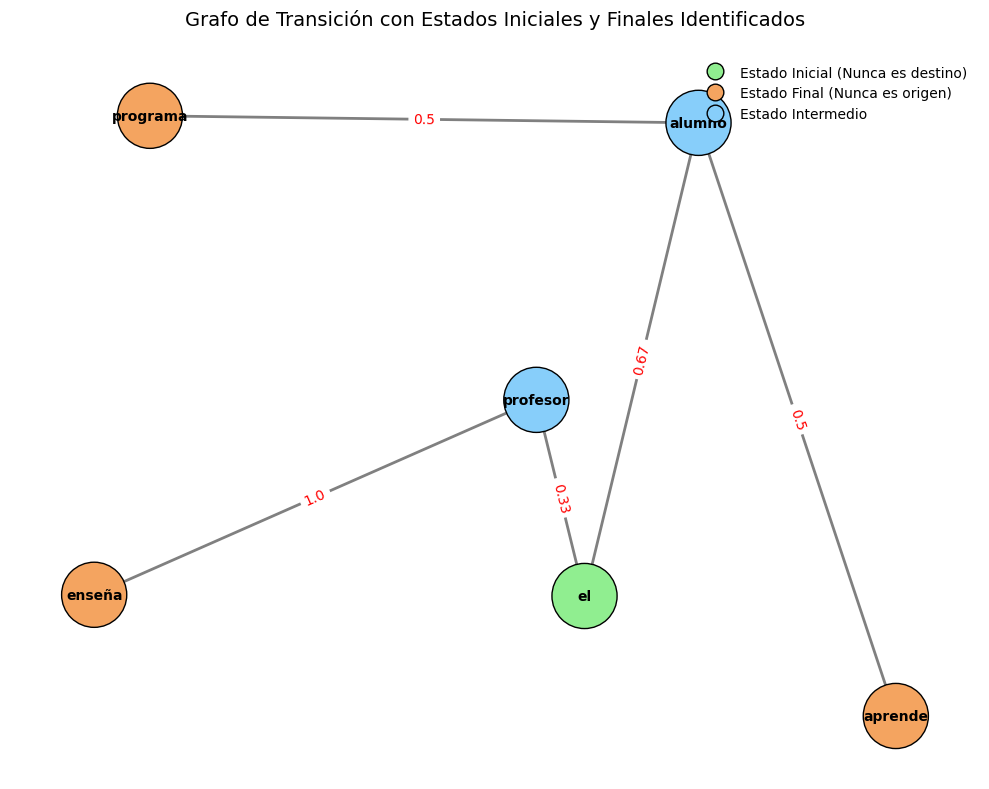

In [31]:
import networkx as nx
import matplotlib.pyplot as plt

# Determinar estados iniciales y finales programáticamente
odos_con_entrada = set()
odos_con_salida = set()

for elemento in matriz_transcicion:
    for (a, b), probabilidad in elemento.items():
        if probabilidad > 0:
            odos_con_salida.add(a)
            odos_con_entrada.add(b)

todos_los_nodos = set(palabras_ordenadas)
estados_iniciales = todos_los_nodos - odos_con_entrada
estados_finales = todos_los_nodos - odos_con_salida

# Crear el grafo dirigido
G = nx.DiGraph()
G.add_nodes_from(palabras_ordenadas)

for elemento in matriz_transcicion:
    for (a, b), probabilidad in elemento.items():
        if probabilidad > 0:
            G.add_edge(a, b, weight=round(probabilidad, 2))

# Asignar colores a los nodos según su rol
colores_nodos = []
for nodo in palabras_ordenadas:
    if nodo in estados_iniciales:
        colores_nodos.append('lightgreen')      # Inicial
    elif nodo in estados_finales:
        colores_nodos.append('sandybrown')      # Final
    else:
        colores_nodos.append('lightskyblue')     # Intermedio

# Configurar y dibujar el grafo
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42, k=1.5)

nx.draw_networkx_nodes(G, pos, node_size=2200, node_color=colores_nodos, edgecolors='black')
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=20, edge_color='gray', width=2)

edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10, font_color='red')

# Añadir una leyenda explicativa
plt.plot([], [], 'o', color='lightgreen', label='Estado Inicial (Nunca es destino)', markersize=12, markeredgecolor='black')
plt.plot([], [], 'o', color='sandybrown', label='Estado Final (Nunca es origen)', markersize=12, markeredgecolor='black')
plt.plot([], [], 'o', color='lightskyblue', label='Estado Intermedio', markersize=12, markeredgecolor='black')
plt.legend(loc='upper right', fontsize=10, frameon=False)

plt.title("Grafo de Transición con Estados Iniciales y Finales Identificados", fontsize=14, pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()